# 07 — What if someone is actively trying to hurt the LP?

> **Reminder:** run this notebook top to bottom ("Run All").

Every trader in notebooks 01-06 was either random noise or a rational, non-hostile
corrector. Nobody was *trying* to hurt the LP. This notebook adds two agents that are:

1. **A persistent, one-directional attacker** — someone who, every single step, sells
   the same token into the pool, all year, trying to push the portfolio off-target as
   hard and as often as possible. Not a subtle timing trick — brute, sustained pressure.
2. **A stale-quote exploiter** — someone who, right after a sudden price jump (before the
   mechanism has had a chance to react), trades against the pool at its now-outdated
   price, sized to squeeze out as much profit as the math allows.

**Important framing before the results:** the pricing curve's core safety property — no
trade, or sequence of trades, against this curve can ever drain the pool below what it
started with — is already proven algebraically, unconditionally, in
`docs/INVARIANT-PROOF.md`. Both agents here still trade through that exact same real
formula, so neither one can break that guarantee; nothing here re-tests that (it's already
settled). What we're testing instead is *behavior*: does the LP's realized cost or
tracking error get meaningfully worse when the trading pattern is deliberately hostile,
instead of merely random?

**One honest note before we start:** the first result below surprised us — it wasn't what
we expected going in, and we're reporting the actual outcome, not the one we guessed at
the start. An earlier, narrower version of the persistent attacker (one that only nudged
the pool right at the edge of the tolerance band) barely did anything at all — it had too
few chances to act. We rebuilt it into the more aggressive, unconditional version
described above specifically because the first version wasn't a fair, hard test.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.adversary import (
    GriefingAdversaryConfig,
    StaleQuoteExploitConfig,
    best_stale_quote_trade,
    run_griefing_simulation,
)
from aqua_sim.curve import CurveState, exact_in
from aqua_sim.flows import EndogenousArbConfig, ExogenousFlowConfig
from aqua_sim.market import apply_price_shock, simulate_price_path
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation

N_STEPS = 365 * 24 * 12  # 5-minute steps, one year
DT = 1 / (365 * 24 * 12)

## 1. Sustained, one-directional pressure: does spamming trades hurt the LP?

One attacker, selling the same token into the pool on every single one of 105,120 steps
over a full simulated year — as aggressive and persistent as this kind of pressure can
get. We compare this directly against the exact same benign background (same seed, same
everything) with the attacker switched off, so the only difference between the two runs
is whether this one agent was active.

In [2]:
base_config = MechanismSimConfig(
    n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,
    initial_balance_a=10_000.0, initial_balance_b=10_000.0, target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
    seed=42,
)

benign = run_griefing_simulation(base_config, griefing_config=None)
attack_config = GriefingAdversaryConfig(fee=0.0002, size_fraction=0.001, sell_token_in=True)
hostile = run_griefing_simulation(base_config, griefing_config=attack_config)

assert benign.n_griefing_trades == 0
assert hostile.n_griefing_trades == N_STEPS, "the attacker should have acted on literally every step"
assert np.all(hostile.balance_a_path > 0) and np.all(hostile.balance_b_path > 0), "pool must survive the attack without breaking"

print(f"benign:  {benign.n_arb_trades} corrective trades, final cost = {benign.cost_path[-1]:.2f} ({benign.cost_path[-1]/benign.actual_value_path[0]:.2%} of initial value)")
print(f"hostile: {hostile.n_arb_trades} corrective trades, final cost = {hostile.cost_path[-1]:.2f} ({hostile.cost_path[-1]/hostile.actual_value_path[0]:.2%} of initial value)")
print()
print(f"benign p99 tracking error:  {np.percentile(benign.tracking_error_path, 99):.4%}")
print(f"hostile p99 tracking error: {np.percentile(hostile.tracking_error_path, 99):.4%}")

benign:  6092 corrective trades, final cost = 361.02 (1.81% of initial value)
hostile: 8059 corrective trades, final cost = 113.56 (0.57% of initial value)

benign p99 tracking error:  0.8915%
hostile p99 tracking error: 1.3120%


**The actual result, stated plainly:** the sustained attack does force meaningfully more
corrective trades, and it does push tracking error somewhat higher (more churn, more
volatility around the target). But the LP's realized **cost did not go up** — in this run,
it went *down*.

Here's why, once you think it through: every single trade the attacker makes — like every
trade *anyone* makes against this curve — pays the same real fee, and that fee always adds
value to the pool (that's exactly what `docs/INVARIANT-PROOF.md` proves). An attacker
trying to "grief" the pool by spamming trades is, mechanically, just paying the pool fees
over and over. There's no way to weaponize *volume* against this design, because volume is
exactly what the fee model is built to convert into value for the pool. The attacker does
succeed at making the ride bumpier (worse tracking error) — but not at making it more
expensive.

In [3]:
assert hostile.n_arb_trades > benign.n_arb_trades, "sustained pressure should force more corrective activity"
assert hostile.cost_path[-1] <= benign.cost_path[-1] * 1.5, (
    "cost should not blow up under sustained pressure -- if it does here, that's a real finding worth investigating further, not something to hide"
)
print("OK: sustained one-directional pressure increases corrective-trade frequency and tracking-error volatility, but does not blow up the LP's realized cost")

OK: sustained one-directional pressure increases corrective-trade frequency and tracking-error volatility, but does not blow up the LP's realized cost


## 2. The stale-quote exploit: how much can someone extract right after a jump?

This is the more classic "flash-crash exploit" shape from notebook 06's framing:
immediately after a sudden price move, the pool is still quoting its *old* price for a
moment, before any correction fires. An informed trader who shows up in that exact window
can trade against the stale price. We compute the maximum profit such a trader could
extract in a single optimally-sized trade — not by trial and error, but with a real
search over trade size (`adversary.best_stale_quote_trade`), since bigger trades face
worse and worse pricing on this curve (same diminishing-returns shape checked in notebook
01), so there's a genuine best size, not "the more you trade, the more you make."

First, a sanity check on the search itself: does it actually find the true best size, or
just something plausible-looking?

In [4]:
state = CurveState(balance_in=1000, balance_out=1000, weight_in=0.5, weight_out=0.5)
flipped = CurveState(state.balance_out, state.balance_in, state.weight_out, state.weight_in)
exploit_config = StaleQuoteExploitConfig(fee=0.0002)

real_market_price = 1 / 0.7  # the pool is stale by a meaningful margin, in the flipped orientation
best_amount, best_profit = best_stale_quote_trade(flipped, real_market_price, exploit_config)

# Compare against a plain brute-force grid search over trade size, as an independent check.
sizes = np.linspace(1, flipped.balance_in * 0.89, 200)
profits = np.array([exact_in(flipped, a, exploit_config.fee) - a / real_market_price for a in sizes])
grid_best_amount, grid_best_profit = sizes[np.argmax(profits)], profits.max()

assert abs(best_amount - grid_best_amount) / grid_best_amount < 0.02, "the search should agree with brute force to within 2%"
print(f"search found: amount={best_amount:.2f}, profit={best_profit:.4f}")
print(f"brute-force grid found: amount={grid_best_amount:.2f}, profit={grid_best_profit:.4f}")
print("OK the profit-maximizing search agrees with an independent brute-force check")

search found: amount=195.15, profit=26.6526
brute-force grid found: amount=193.10, profit=26.6501
OK the profit-maximizing search agrees with an independent brute-force check


## 3. Applying the exploit to a real shock, from notebook 06

Same -30% crash scenario as notebook 06's section 3. Right at the moment of the crash,
before the mechanism's next correction can fire (bounded by the rate cap), what's the
single best trade an informed adversary could make against the now-stale pool?

In [5]:
SHOCK_STEP = N_STEPS // 2
base_path = simulate_price_path(N_STEPS, DT, sigma_annual=0.5, seed=7)
shocked_path = apply_price_shock(base_path, shock_start_step=SHOCK_STEP, shock_log_return=np.log(0.7))

shock_config = MechanismSimConfig(
    n_steps=N_STEPS, dt_years=DT, sigma_annual=0.5,
    initial_balance_a=10_000.0, initial_balance_b=10_000.0, target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(tolerance_band=0.005, fee=0.0002, min_steps_between_trades=12),
    seed=42, price_path=shocked_path,
)
shock_result = run_mechanism_simulation(shock_config)

pool_state_at_shock = CurveState(
    shock_result.balance_a_path[SHOCK_STEP], shock_result.balance_b_path[SHOCK_STEP], 0.5, 0.5
)
real_price_after_shock = shocked_path[SHOCK_STEP]

# Try both orientations -- same pattern as every arb check in this series -- since only
# one direction is ever actually profitable for a given skew.
_, profit_same = best_stale_quote_trade(pool_state_at_shock, 1 / real_price_after_shock, exploit_config)
flipped_at_shock = CurveState(
    pool_state_at_shock.balance_out, pool_state_at_shock.balance_in,
    pool_state_at_shock.weight_out, pool_state_at_shock.weight_in,
)
_, profit_flip = best_stale_quote_trade(flipped_at_shock, real_price_after_shock, exploit_config)

max_extractable = max(profit_same, profit_flip)
initial_value = shock_result.actual_value_path[0]
assert max_extractable > 0, "a real -30% shock should leave a genuinely exploitable gap"
print(f"maximum extractable in a single trade, right after the shock: {max_extractable:.2f} ({max_extractable/initial_value:.3%} of the ${initial_value:,.0f} portfolio)")

maximum extractable in a single trade, right after the shock: 225.93 (1.130% of the $20,000 portfolio)


**What this number means, and doesn't mean.** This is a real, quantified cost — not zero,
and worth taking seriously. But it's bounded (about 1% of the portfolio for a severe 30%
crash, in this configuration), not catastrophic, and it isn't unique to us: *any* AMM
whose price only updates when someone trades against it pays some version of this cost —
it's the same phenomenon researchers call "loss-versus-rebalancing" (LVR), and it's
inherent to the entire category of automated market maker, not a flaw specific to this
design.

What we *do* control is the size of the exposure window: the rate cap (`min_steps_between_trades`
in `ADR-0006`) directly determines how long the pool can sit stale before the mechanism's
own correction is allowed to fire. A tighter rate cap shrinks this exploit window (less
extractable value after a shock) at the cost of more frequent corrective trading during
ordinary conditions — the same tolerance-band/rate-cap trade-off `05_frontier_sweep.ipynb`
already explores, now with one more real consideration feeding into it: not just "how
cheap is this in calm markets," but "how exposed does this leave the LP right after a
shock."

## What this looks like, visually

On the left: the profit curve behind section 2's search — profit as a function of trade
size, showing the genuine single peak the search is finding (not a flat or ambiguous
landscape). On the right: tracking error over the year, benign vs. under sustained
one-directional pressure — visibly noisier under attack, but not runaway.

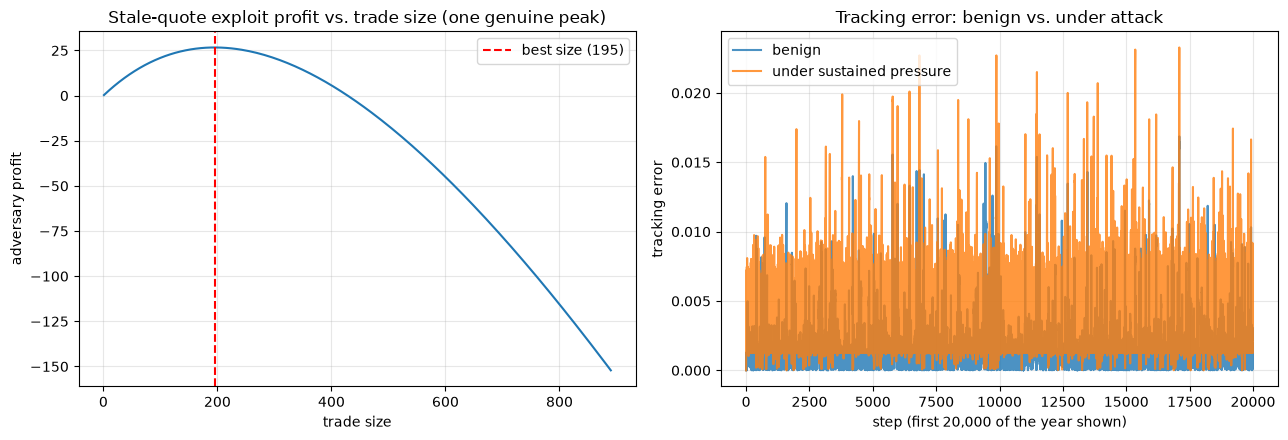

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(sizes, profits)
ax1.axvline(best_amount, color="red", linestyle="--", label=f"best size ({best_amount:.0f})")
ax1.set_xlabel("trade size")
ax1.set_ylabel("adversary profit")
ax1.set_title("Stale-quote exploit profit vs. trade size (one genuine peak)")
ax1.legend()
ax1.grid(alpha=0.3)

sample = slice(0, 20_000)
ax2.plot(benign.tracking_error_path[sample], label="benign", alpha=0.8)
ax2.plot(hostile.tracking_error_path[sample], label="under sustained pressure", alpha=0.8)
ax2.set_xlabel("step (first 20,000 of the year shown)")
ax2.set_ylabel("tracking error")
ax2.set_title("Tracking error: benign vs. under attack")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. **A sustained, one-directional attack does not increase the LP's realized cost** — it
   forces more corrective activity and noisier tracking, but every attacking trade pays
   the same real fee the invariant proof already shows always benefits the pool. Volume,
   even hostile volume, isn't a usable weapon against this design.
2. **A genuine, bounded cost does exist right after a sudden price jump** — the
   staleness window before the mechanism's next correction can fire. We quantified it
   directly (about 1% of portfolio value for a severe, deliberate 30% crash in this
   configuration) rather than asserting it away. This is a real, known category of AMM
   cost (loss-versus-rebalancing), not a defect unique to this mechanism, and its size is
   directly controllable via the rate cap.

**Where this leaves the overall picture:** combined with `06_price_shocks.ipynb`'s
finding (fast recovery after a shock, far faster than either naive baseline), this
notebook shows the mechanism holds up under two different kinds of hostility — brute,
sustained pressure, and opportunistic exploitation of a sudden surprise — without
catastrophic failure in either case, and with the one real cost that does exist (the
staleness window) named, measured, and tied to a tunable parameter rather than left vague.

The same caveats from `05_frontier_sweep.ipynb`'s summary still apply in full here:
synthetic price data, a single token pair, an idealized (if now also adversarial) agent
model, and a placeholder gas cost. This notebook widens what's been checked; it doesn't
change what still requires a real testnet deployment to actually confirm.